# Cybersecurity Threat Detection & Analysis Using Python

This project analyzes cybersecurity event data to identify threats, attack patterns, security indicators, risk levels, and suspicious activities using Python.

## 1. Import Libraries

In this section, the required Python libraries are imported for data manipulation, numerical analysis, and data visualization.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load Dataset

The cybersecurity dataset is loaded into a Pandas DataFrame for further analysis.

In [4]:
df = pd.read_csv(r"C:\Users\USER\Downloads\cybersecurity_threat_dataset.csv")

## 3. Initial Data Inspection

The dataset structure, dimensions, column names, data types, and initial records are examined to understand the data before cleaning.

In [6]:
df.shape

(5255, 42)

In [7]:
df.head()

,Event_ID,Timestamp,Source_IP,Destination_IP,Source_Port,Destination_Port,Protocol,Packet_Count,Bytes_Sent,Bytes_Received,...,Detection_Method,Device_Type,Operating_System,Browser,Country,Region,Network_Type,Is_Threat,Is_Malicious,Incident_Status
0,EVT104140,2025-03-13 15:52:53,72.53.209.118,192.168.52.203,22,443,ICMP,100,6376,7363.0,...,IDS/IPS,Server,Windows 11,Edge,China,West,VPN,0,0,False Positive
1,EVT104454,2025-03-18 20:10:31,192.168.248.11,80.197.249.68,80,110,TCP,134,6351,11325.0,...,Firewall,Server,iOS,Unknown,Brazil,North,Wi-Fi,0,0,False Positive
2,EVT100961,2025-01-17 02:42:30,105.75.122.186,192.168.43.169,110,110,SSH,177,1655,1042.0,...,Firewall,Desktop,Windows 11,Unknown,UK,South,VPN,0,0,Resolved
3,EVT101005,2025-01-17 17:11:00,192.168.169.4,192.168.10.206,22,80,FTP,77,1580,762.0,...,SIEM,Mobile,Windows 11,Unknown,Canada,West,VPN,0,0,Resolved
4,EVT104174,2025-03-14 04:44:43,116.135.142.96,192.168.208.171,3306,3389,HTTP,1346,20352,10276.0,...,IDS/IPS,Desktop,Windows 11,Unknown,Brazil,Central,VPN,1,1,Escalated


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5255 entries, 0 to 5254
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event_ID                5255 non-null   str    
 1   Timestamp               5255 non-null   str    
 2   Source_IP               5255 non-null   str    
 3   Destination_IP          5255 non-null   str    
 4   Source_Port             5255 non-null   int64  
 5   Destination_Port        5255 non-null   int64  
 6   Protocol                5255 non-null   str    
 7   Packet_Count            5255 non-null   int64  
 8   Bytes_Sent              5255 non-null   int64  
 9   Bytes_Received          5125 non-null   float64
 10  Connection_Duration     5255 non-null   float64
 11  Request_Count           5255 non-null   int64  
 12  Response_Time           5043 non-null   float64
 13  Login_Attempts          5255 non-null   int64  
 14  Failed_Login_Count      5255 non-null   int64  
 15

In [10]:
df.describe()

,Source_Port,Destination_Port,Packet_Count,Bytes_Sent,Bytes_Received,Connection_Duration,Request_Count,Response_Time,Login_Attempts,Failed_Login_Count,...,Session_Duration,Malware_Detected,Encryption_Used,Suspicious_URL,Unusual_Port,Multiple_Failed_Logins,Anomaly_Score,Risk_Score,Is_Threat,Is_Malicious
count,5255.000000,5255.000000,5255.000000,5.255000e+03,5125.000000,5255.000000,5255.000000,5043.000000,5255.000000,5255.000000,...,5176.000000,5255.000000,5255.000000,5255.00000,5255.000000,5255.000000,5255.000000,5255.000000,5255.000000,5255.000000
mean,9013.659943,2818.115699,265.412750,1.441643e+04,8529.705756,49.045265,40.578116,1.247148,2.328259,1.619410,...,24.025394,0.104091,0.731874,0.10314,0.089439,0.084681,28.929007,27.649665,0.159277,0.120837
std,16378.307770,6837.221409,516.428187,6.225680e+04,8136.181151,115.916180,57.184609,1.293964,2.332666,2.388305,...,14.022042,0.305408,0.443026,0.30417,0.285403,0.278433,23.313556,24.601944,0.365969,0.325969
min,21.000000,21.000000,1.000000,6.000000e+00,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,...,0.020000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,53.000000,25.000000,118.000000,3.634000e+03,4259.000000,20.990000,15.000000,0.577000,1.000000,0.000000,...,12.957500,0.000000,0.000000,0.00000,0.000000,0.000000,13.710000,12.470000,0.000000,0.000000
50%,443.000000,110.000000,164.000000,5.582000e+03,6521.000000,32.550000,22.000000,0.900000,2.000000,1.000000,...,23.335000,0.000000,1.000000,0.00000,0.000000,0.000000,22.800000,20.050000,0.000000,0.000000
75%,8080.000000,3389.000000,224.000000,8.080000e+03,9212.000000,46.380000,31.000000,1.265000,3.000000,2.000000,...,33.415000,0.000000,1.000000,0.00000,0.000000,0.000000,34.355000,30.390000,0.000000,0.000000
max,65532.000000,54321.000000,25428.000000,3.190530e+06,59927.000000,6305.460000,362.000000,9.317000,19.000000,18.000000,...,84.130000,1.000000,1.000000,1.00000,1.000000,1.000000,100.000000,100.000000,1.000000,1.000000


In [11]:
df.nunique()

Event_ID                  5200
Timestamp                 5198
Source_IP                 5141
Destination_IP            5144
Source_Port               1219
Destination_Port            18
Protocol                    16
Packet_Count               884
Bytes_Sent                4300
Bytes_Received            4245
Connection_Duration       3731
Request_Count              291
Response_Time             2103
Login_Attempts              18
Failed_Login_Count          18
Successful_Login_Count       2
Session_Duration          3230
Authentication_Method        6
Malware_Detected             2
Firewall_Status              3
Antivirus_Status             3
Encryption_Used              2
Suspicious_URL               2
Unusual_Port                 2
Multiple_Failed_Logins       2
Anomaly_Score             3324
Risk_Score                3172
Threat_Type                  9
Attack_Type                  9
Attack_Vector                7
Severity                     4
Threat_Status                3
Detectio

In [12]:
df.isnull().sum()

Event_ID                     0
Timestamp                    0
Source_IP                    0
Destination_IP               0
Source_Port                  0
Destination_Port             0
Protocol                     0
Packet_Count                 0
Bytes_Sent                   0
Bytes_Received             130
Connection_Duration          0
Request_Count                0
Response_Time              212
Login_Attempts               0
Failed_Login_Count           0
Successful_Login_Count       0
Session_Duration            79
Authentication_Method      105
Malware_Detected             0
Firewall_Status              0
Antivirus_Status           158
Encryption_Used              0
Suspicious_URL               0
Unusual_Port                 0
Multiple_Failed_Logins       0
Anomaly_Score                0
Risk_Score                   0
Threat_Type               4418
Attack_Type               4418
Attack_Vector             4418
Severity                     0
Threat_Status             4418
Detectio

## 4. Data Cleaning

Missing values and duplicate records are identified and handled appropriately while preserving meaningful cybersecurity information.

In [13]:
df.duplicated().sum()

np.int64(55)

In [14]:
df[df.duplicated()]

,Event_ID,Timestamp,Source_IP,Destination_IP,Source_Port,Destination_Port,Protocol,Packet_Count,Bytes_Sent,Bytes_Received,...,Detection_Method,Device_Type,Operating_System,Browser,Country,Region,Network_Type,Is_Threat,Is_Malicious,Incident_Status
775,EVT100078,2025-01-02 09:15:10,21.9.131.56,141.216.56.199,25,21,HTTPS,172,4898,5711.0,...,SIEM,Laptop,Windows 10,NaN,Russia,Central,Wi-Fi,0,0,Resolved
1576,EVT104918,2025-03-27 03:11:50,196.252.226.90,192.168.140.241,8080,6666,TCP,739,81938,39076.0,...,IDS/IPS,Server,Android,Edge,UK,South,Wi-Fi,1,1,Under Investigation
1712,EVT104567,2025-03-20 17:21:20,191.150.30.209,192.168.181.167,3389,22,SSH,146,4191,4689.0,...,SIEM,Tablet,Android,Edge,Australia,North,VPN,0,0,Resolved
1739,EVT103950,2025-03-10 02:32:13,192.168.10.102,192.168.253.253,3389,22,HTTPS,122,2517,3875.0,...,SIEM,Tablet,Android,Firefox,Canada,South,LAN,0,0,Resolved
1824,EVT101542,2025-01-27 05:59:28,192.168.65.63,192.168.249.20,25,3389,FTP,202,8355,9322.0,...,Firewall,Mobile,macOS,Unknown,Canada,North,LAN,0,0,Resolved
1903,EVT103033,2025-02-22 11:49:30,32.89.191.107,107.218.133.11,22,8080,TCP,211,5773,5880.0,...,Firewall,Tablet,macOS,Edge,Singapore,West,Public Network,0,0,False Positive
1980,EVT102350,2025-02-10 03:08:59,79.41.7.210,192.168.68.12,48639,22,ICMP,172,6524,15591.0,...,IDS/IPS,Server,macOS,Safari,Brazil,South,Public Network,0,0,False Positive
2085,EVT104137,2025-03-13 14:10:18,186.159.6.182,192.168.51.112,19531,22,DNS,183,8002,5268.0,...,SIEM,Tablet,Windows Server 2019,Safari,Russia,South,VPN,0,0,Resolved
2147,EVT101874,2025-02-01 23:37:50,192.168.122.155,192.168.213.170,3306,3389,ICMP,150,6637,8815.0,...,Firewall,Desktop,Windows Server 2019,Firefox,Singapore,East,Wi-Fi,0,0,False Positive
2169,EVT104994,2025-03-28 11:35:15,129.244.253.99,192.168.54.227,3389,443,SSH,190,5729,9710.0,...,Firewall,Desktop,Linux,Safari,Canada,North,VPN,0,0,False Positive


In [17]:
df.select_dtypes(include=["object","str"]).nunique()

Event_ID                 5200
Timestamp                5198
Source_IP                5141
Destination_IP           5144
Protocol                   16
Authentication_Method       6
Firewall_Status             3
Antivirus_Status            3
Threat_Type                 9
Attack_Type                 9
Attack_Vector               7
Severity                    4
Threat_Status               3
Detection_Method            7
Device_Type                 6
Operating_System            7
Browser                     6
Country                    19
Region                      5
Network_Type                5
Incident_Status             5
dtype: int64

In [18]:
df.select_dtypes(include=np.number).describe()

,Source_Port,Destination_Port,Packet_Count,Bytes_Sent,Bytes_Received,Connection_Duration,Request_Count,Response_Time,Login_Attempts,Failed_Login_Count,...,Session_Duration,Malware_Detected,Encryption_Used,Suspicious_URL,Unusual_Port,Multiple_Failed_Logins,Anomaly_Score,Risk_Score,Is_Threat,Is_Malicious
count,5255.000000,5255.000000,5255.000000,5.255000e+03,5125.000000,5255.000000,5255.000000,5043.000000,5255.000000,5255.000000,...,5176.000000,5255.000000,5255.000000,5255.00000,5255.000000,5255.000000,5255.000000,5255.000000,5255.000000,5255.000000
mean,9013.659943,2818.115699,265.412750,1.441643e+04,8529.705756,49.045265,40.578116,1.247148,2.328259,1.619410,...,24.025394,0.104091,0.731874,0.10314,0.089439,0.084681,28.929007,27.649665,0.159277,0.120837
std,16378.307770,6837.221409,516.428187,6.225680e+04,8136.181151,115.916180,57.184609,1.293964,2.332666,2.388305,...,14.022042,0.305408,0.443026,0.30417,0.285403,0.278433,23.313556,24.601944,0.365969,0.325969
min,21.000000,21.000000,1.000000,6.000000e+00,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,...,0.020000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,53.000000,25.000000,118.000000,3.634000e+03,4259.000000,20.990000,15.000000,0.577000,1.000000,0.000000,...,12.957500,0.000000,0.000000,0.00000,0.000000,0.000000,13.710000,12.470000,0.000000,0.000000
50%,443.000000,110.000000,164.000000,5.582000e+03,6521.000000,32.550000,22.000000,0.900000,2.000000,1.000000,...,23.335000,0.000000,1.000000,0.00000,0.000000,0.000000,22.800000,20.050000,0.000000,0.000000
75%,8080.000000,3389.000000,224.000000,8.080000e+03,9212.000000,46.380000,31.000000,1.265000,3.000000,2.000000,...,33.415000,0.000000,1.000000,0.00000,0.000000,0.000000,34.355000,30.390000,0.000000,0.000000
max,65532.000000,54321.000000,25428.000000,3.190530e+06,59927.000000,6305.460000,362.000000,9.317000,19.000000,18.000000,...,84.130000,1.000000,1.000000,1.00000,1.000000,1.000000,100.000000,100.000000,1.000000,1.000000


In [20]:
missing = df.isnull().sum()
missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": (missing / len(df)) * 100
})
missing_summary[missing_summary["Missing_Count"] > 0].sort_values(
    "Missing_Count", ascending=False
)

,Missing_Count,Missing_Percentage
Threat_Status,4418,84.072312
Threat_Type,4418,84.072312
Attack_Type,4418,84.072312
Attack_Vector,4418,84.072312
Response_Time,212,4.034253
Antivirus_Status,158,3.006660
Bytes_Received,130,2.473834
Country,106,2.017127
Browser,106,2.017127
Authentication_Method,105,1.998097


In [21]:
df[df["Threat_Type"].isnull()]["Is_Threat"].value_counts()

Is_Threat
0    4418
Name: count, dtype: int64

In [22]:
df[df["Attack_Type"].isnull()]["Is_Threat"].value_counts()

Is_Threat
0    4418
Name: count, dtype: int64

In [23]:
df[df["Threat_Status"].isnull()]["Is_Threat"].value_counts()

Is_Threat
0    4418
Name: count, dtype: int64

In [24]:
df[df["Bytes_Received"].isnull()]["Is_Threat"].value_counts()

Is_Threat
0    111
1     19
Name: count, dtype: int64

In [25]:
df[df["Response_Time"].isnull()]["Is_Threat"].value_counts()

Is_Threat
0    176
1     36
Name: count, dtype: int64

In [26]:
df[df["Authentication_Method"].isnull()]["Is_Threat"].value_counts()

Is_Threat
0    93
1    12
Name: count, dtype: int64

In [27]:
df[df["Antivirus_Status"].isnull()]["Is_Threat"].value_counts()

Is_Threat
0    134
1     24
Name: count, dtype: int64

### 4.1 Handling Categorical Missing Values

Missing categorical values are replaced with "Unknown" where appropriate.

In [ ]:
categorical_missing_cols = [
    "Authentication_Method",
    "Antivirus_Status",
    "Browser",
    "Country"
]
for col in categorical_missing_cols:
    df[col] = df[col].fillna("Unknown")

In [9]:
df.isnull().sum()

Event_ID                     0
Timestamp                    0
Source_IP                    0
Destination_IP               0
Source_Port                  0
Destination_Port             0
Protocol                     0
Packet_Count                 0
Bytes_Sent                   0
Bytes_Received             130
Connection_Duration          0
Request_Count                0
Response_Time              212
Login_Attempts               0
Failed_Login_Count           0
Successful_Login_Count       0
Session_Duration            79
Authentication_Method        0
Malware_Detected             0
Firewall_Status              0
Antivirus_Status             0
Encryption_Used              0
Suspicious_URL               0
Unusual_Port                 0
Multiple_Failed_Logins       0
Anomaly_Score                0
Risk_Score                   0
Threat_Type               4418
Attack_Type               4418
Attack_Vector             4418
Severity                     0
Threat_Status             4418
Detectio

### 4.2 Handling Numerical Missing Values

Missing numerical values are filled using group-wise median values to preserve meaningful differences between threat and non-threat events.

In [10]:
numeric_missing_cols = [
    "Bytes_Received",
    "Response_Time",
    "Session_Duration"
]
for col in numeric_missing_cols:
    df[col] = df.groupby("Is_Threat")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [11]:
numeric_missing_cols = [
    "Bytes_Received",
    "Response_Time",
    "Session_Duration"
]
for col in numeric_missing_cols:
    df[col] = df.groupby("Is_Threat")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [12]:
df.isnull().sum()

Event_ID                     0
Timestamp                    0
Source_IP                    0
Destination_IP               0
Source_Port                  0
Destination_Port             0
Protocol                     0
Packet_Count                 0
Bytes_Sent                   0
Bytes_Received               0
Connection_Duration          0
Request_Count                0
Response_Time                0
Login_Attempts               0
Failed_Login_Count           0
Successful_Login_Count       0
Session_Duration             0
Authentication_Method        0
Malware_Detected             0
Firewall_Status              0
Antivirus_Status             0
Encryption_Used              0
Suspicious_URL               0
Unusual_Port                 0
Multiple_Failed_Logins       0
Anomaly_Score                0
Risk_Score                   0
Threat_Type               4418
Attack_Type               4418
Attack_Vector             4418
Severity                     0
Threat_Status             4418
Detectio

## 5. Duplicate Data Cleaning

Duplicate records are identified and removed to ensure each event is represented only once.

In [13]:
df.duplicated().sum()

np.int64(55)

In [14]:
df[df.duplicated()]

,Event_ID,Timestamp,Source_IP,Destination_IP,Source_Port,Destination_Port,Protocol,Packet_Count,Bytes_Sent,Bytes_Received,...,Detection_Method,Device_Type,Operating_System,Browser,Country,Region,Network_Type,Is_Threat,Is_Malicious,Incident_Status
775,EVT100078,2025-01-02 09:15:10,21.9.131.56,141.216.56.199,25,21,HTTPS,172,4898,5711.0,...,SIEM,Laptop,Windows 10,Unknown,Russia,Central,Wi-Fi,0,0,Resolved
1576,EVT104918,2025-03-27 03:11:50,196.252.226.90,192.168.140.241,8080,6666,TCP,739,81938,39076.0,...,IDS/IPS,Server,Android,Edge,UK,South,Wi-Fi,1,1,Under Investigation
1712,EVT104567,2025-03-20 17:21:20,191.150.30.209,192.168.181.167,3389,22,SSH,146,4191,4689.0,...,SIEM,Tablet,Android,Edge,Australia,North,VPN,0,0,Resolved
1739,EVT103950,2025-03-10 02:32:13,192.168.10.102,192.168.253.253,3389,22,HTTPS,122,2517,3875.0,...,SIEM,Tablet,Android,Firefox,Canada,South,LAN,0,0,Resolved
1824,EVT101542,2025-01-27 05:59:28,192.168.65.63,192.168.249.20,25,3389,FTP,202,8355,9322.0,...,Firewall,Mobile,macOS,Unknown,Canada,North,LAN,0,0,Resolved
1903,EVT103033,2025-02-22 11:49:30,32.89.191.107,107.218.133.11,22,8080,TCP,211,5773,5880.0,...,Firewall,Tablet,macOS,Edge,Singapore,West,Public Network,0,0,False Positive
1980,EVT102350,2025-02-10 03:08:59,79.41.7.210,192.168.68.12,48639,22,ICMP,172,6524,15591.0,...,IDS/IPS,Server,macOS,Safari,Brazil,South,Public Network,0,0,False Positive
2085,EVT104137,2025-03-13 14:10:18,186.159.6.182,192.168.51.112,19531,22,DNS,183,8002,5268.0,...,SIEM,Tablet,Windows Server 2019,Safari,Russia,South,VPN,0,0,Resolved
2147,EVT101874,2025-02-01 23:37:50,192.168.122.155,192.168.213.170,3306,3389,ICMP,150,6637,8815.0,...,Firewall,Desktop,Windows Server 2019,Firefox,Singapore,East,Wi-Fi,0,0,False Positive
2169,EVT104994,2025-03-28 11:35:15,129.244.253.99,192.168.54.227,3389,443,SSH,190,5729,9710.0,...,Firewall,Desktop,Linux,Safari,Canada,North,VPN,0,0,False Positive


In [15]:
df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.shape

(5200, 42)

In [18]:
df.dtypes

Event_ID                      str
Timestamp                     str
Source_IP                     str
Destination_IP                str
Source_Port                 int64
Destination_Port            int64
Protocol                      str
Packet_Count                int64
Bytes_Sent                  int64
Bytes_Received            float64
Connection_Duration       float64
Request_Count               int64
Response_Time             float64
Login_Attempts              int64
Failed_Login_Count          int64
Successful_Login_Count      int64
Session_Duration          float64
Authentication_Method         str
Malware_Detected            int64
Firewall_Status               str
Antivirus_Status              str
Encryption_Used             int64
Suspicious_URL              int64
Unusual_Port                int64
Multiple_Failed_Logins      int64
Anomaly_Score             float64
Risk_Score                float64
Threat_Type                   str
Attack_Type                   str
Attack_Vector 

## 6. Data Type & Consistency Check

Data types and categorical values are checked to ensure the dataset is consistent and ready for analysis.

In [19]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [20]:
df["Timestamp"].dtype

dtype('<M8[us]')

In [21]:
df["Is_Threat"].value_counts()
df["Is_Malicious"].value_counts()

Is_Malicious
0    4572
1     628
Name: count, dtype: int64

In [22]:
df["Is_Threat"].value_counts()

Is_Threat
0    4370
1     830
Name: count, dtype: int64

In [23]:
categorical_cols = df.select_dtypes(include=["object", "str"]).columns
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Event_ID
<ArrowStringArray>
['EVT104140', 'EVT104454', 'EVT100961', 'EVT101005', 'EVT104174', 'EVT103341',
 'EVT102868', 'EVT100218', 'EVT103927', 'EVT100304',
 ...
 'EVT103885', 'EVT100688', 'EVT103864', 'EVT104946', 'EVT100583', 'EVT100332',
 'EVT101293', 'EVT104023', 'EVT103775', 'EVT101945']
Length: 5200, dtype: str

Source_IP
<ArrowStringArray>
[  '72.53.209.118',  '192.168.248.11',  '105.75.122.186',   '192.168.169.4',
  '116.135.142.96',  '192.168.237.18',  '51.221.132.100',   '68.89.192.168',
  '192.168.28.209',  '171.165.131.42',
 ...
 '192.168.146.203',   '39.116.198.29',    '67.55.61.102', '192.168.190.140',
  '192.168.191.43',  '14.137.248.187', '192.168.132.161', '192.168.109.214',
 '192.168.150.147',    '48.16.12.108']
Length: 5141, dtype: str

Destination_IP
<ArrowStringArray>
[ '192.168.52.203',   '80.197.249.68',  '192.168.43.169',  '192.168.10.206',
 '192.168.208.171',  '123.40.176.220', '192.168.113.120',  '192.168.39.133',
    '2.180.21.144',   '71.31.195.100',
 ..

In [24]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    print(f"{col}: {df[col].dtype}")

Source_Port: int64
Destination_Port: int64
Packet_Count: int64
Bytes_Sent: int64
Bytes_Received: float64
Connection_Duration: float64
Request_Count: int64
Response_Time: float64
Login_Attempts: int64
Failed_Login_Count: int64
Successful_Login_Count: int64
Session_Duration: float64
Malware_Detected: int64
Encryption_Used: int64
Suspicious_URL: int64
Unusual_Port: int64
Multiple_Failed_Logins: int64
Anomaly_Score: float64
Risk_Score: float64
Is_Threat: int64
Is_Malicious: int64


In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 5200 entries, 0 to 5254
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Event_ID                5200 non-null   str           
 1   Timestamp               5200 non-null   datetime64[us]
 2   Source_IP               5200 non-null   str           
 3   Destination_IP          5200 non-null   str           
 4   Source_Port             5200 non-null   int64         
 5   Destination_Port        5200 non-null   int64         
 6   Protocol                5200 non-null   str           
 7   Packet_Count            5200 non-null   int64         
 8   Bytes_Sent              5200 non-null   int64         
 9   Bytes_Received          5200 non-null   float64       
 10  Connection_Duration     5200 non-null   float64       
 11  Request_Count           5200 non-null   int64         
 12  Response_Time           5200 non-null   float64       
 13  Logi

## 7. Exploratory Data Analysis

The dataset is explored using frequency distributions and statistical summaries to understand cybersecurity patterns.

In [26]:
df["Is_Threat"].value_counts()

Is_Threat
0    4370
1     830
Name: count, dtype: int64

In [27]:
df["Is_Threat"].value_counts(normalize=True) * 100

Is_Threat
0    84.038462
1    15.961538
Name: proportion, dtype: float64

In [28]:
df["Threat_Type"].value_counts()

Threat_Type
Port Scanning        101
Man-in-the-Middle     96
Ransomware            94
DDoS                  93
Malware               91
Brute Force           90
Phishing              89
Insider Threat        89
SQL Injection         87
Name: count, dtype: int64

In [29]:
df["Attack_Type"].value_counts()

Attack_Type
Port Scanning        101
Man-in-the-Middle     96
Ransomware            94
DDoS                  93
Malware               91
Brute Force           90
Phishing              89
Insider Threat        89
SQL Injection         87
Name: count, dtype: int64

In [30]:
df["Severity"].value_counts()

Severity
Low         4484
High         317
Medium       302
Critical      97
Name: count, dtype: int64

In [31]:
df["Risk_Score"].describe()

count    5200.000000
mean       27.670196
std        24.609310
min         0.000000
25%        12.502500
50%        20.070000
75%        30.370000
max       100.000000
Name: Risk_Score, dtype: float64

In [32]:
df["Anomaly_Score"].describe()

count    5200.000000
mean       28.960233
std        23.356299
min         0.000000
25%        13.707500
50%        22.800000
75%        34.410000
max       100.000000
Name: Anomaly_Score, dtype: float64

In [33]:
df["Malware_Detected"].value_counts()

Malware_Detected
0    4659
1     541
Name: count, dtype: int64

In [34]:
df["Suspicious_URL"].value_counts()

Suspicious_URL
0    4662
1     538
Name: count, dtype: int64

In [35]:
df["Unusual_Port"].value_counts()

Unusual_Port
0    4734
1     466
Name: count, dtype: int64

## 8. Outlier Analysis

Numerical variables are analyzed using the IQR method and boxplots to identify unusual observations.

In [36]:
outlier_cols = [
    "Packet_Count",
    "Bytes_Sent",
    "Bytes_Received",
    "Connection_Duration",
    "Request_Count",
    "Response_Time",
    "Login_Attempts",
    "Failed_Login_Count",
    "Session_Duration",
    "Anomaly_Score",
    "Risk_Score"
]

In [37]:
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Packet_Count: 762 outliers
Bytes_Sent: 798 outliers
Bytes_Received: 526 outliers
Connection_Duration: 569 outliers
Request_Count: 725 outliers
Response_Time: 620 outliers
Login_Attempts: 350 outliers
Failed_Login_Count: 393 outliers
Session_Duration: 19 outliers
Anomaly_Score: 622 outliers
Risk_Score: 784 outliers


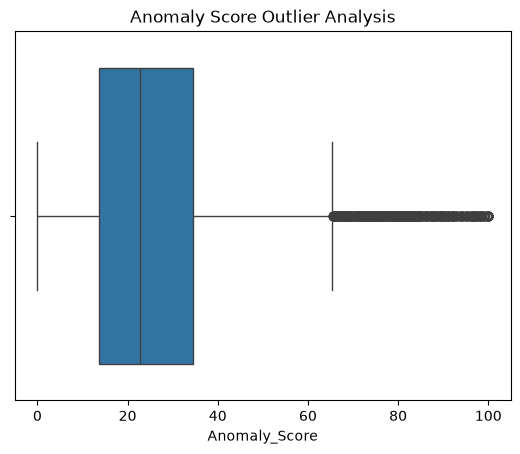

In [38]:
sns.boxplot(x=df["Anomaly_Score"])
plt.title("Anomaly Score Outlier Analysis")
plt.show()

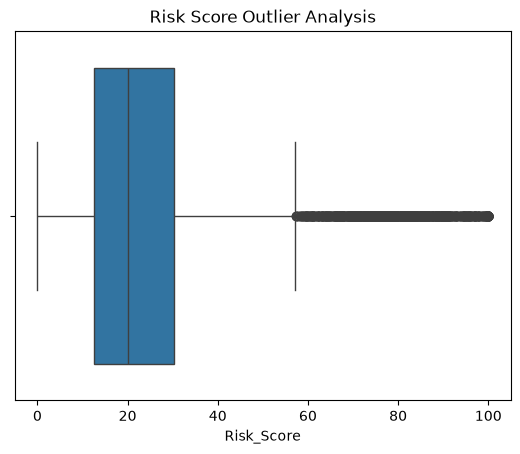

In [39]:
sns.boxplot(x=df["Risk_Score"])
plt.title("Risk Score Outlier Analysis")
plt.show()

## 9. NumPy Numerical Analysis

NumPy is used to perform statistical calculations and compare numerical characteristics of threat and non-threat events.

In [40]:
risk_scores = np.array(df["Risk_Score"])
print(risk_scores)

[28.7  19.93  4.88 ...  5.42  8.27  2.95]


In [41]:
print("Mean:", np.mean(risk_scores))
print("Median:", np.median(risk_scores))
print("Minimum:", np.min(risk_scores))
print("Maximum:", np.max(risk_scores))
print("Standard Deviation:", np.std(risk_scores))

Mean: 27.670196153846156
Median: 20.07
Minimum: 0.0
Maximum: 100.0
Standard Deviation: 24.60694349240569


In [42]:
anomaly_scores = np.array(df["Anomaly_Score"])

print("Mean:", np.mean(anomaly_scores))
print("Median:", np.median(anomaly_scores))
print("Minimum:", np.min(anomaly_scores))
print("Maximum:", np.max(anomaly_scores))
print("Standard Deviation:", np.std(anomaly_scores))

Mean: 28.960232692307695
Median: 22.8
Minimum: 0.0
Maximum: 100.0
Standard Deviation: 23.35405344580894


In [43]:
threat_risk = np.array(
    df[df["Is_Threat"] == 1]["Risk_Score"]
)
non_threat_risk = np.array(
    df[df["Is_Threat"] == 0]["Risk_Score"]
)
print("Threat - Average Risk Score:", np.mean(threat_risk))
print("Non-Threat - Average Risk Score:", np.mean(non_threat_risk))

Threat - Average Risk Score: 78.87020481927712
Non-Threat - Average Risk Score: 17.94570938215103


In [44]:
threat_anomaly = np.array(
    df[df["Is_Threat"] == 1]["Anomaly_Score"]
)

non_threat_anomaly = np.array(
    df[df["Is_Threat"] == 0]["Anomaly_Score"]
)

print("Threat - Average Anomaly Score:", np.mean(threat_anomaly))
print("Non-Threat - Average Anomaly Score:", np.mean(non_threat_anomaly))

Threat - Average Anomaly Score: 75.19421686746988
Non-Threat - Average Anomaly Score: 20.17894965675057


In [45]:
high_risk = risk_scores[risk_scores > 70]

print("High Risk Events:", len(high_risk))

High Risk Events: 625


## 10. Cybersecurity Threat Analysis

Threat events are analyzed to identify attack patterns, security indicators, risk levels, and suspicious behavior.

In [46]:
threat_counts = df["Is_Threat"].value_counts()

print("Non-Threat:", threat_counts[0])
print("Threat:", threat_counts[1])

Non-Threat: 4370
Threat: 830


In [48]:
threat_percentage = df["Is_Threat"].value_counts(normalize=True) * 100

print(threat_percentage)

Is_Threat
0    84.038462
1    15.961538
Name: proportion, dtype: float64


In [49]:
threat_type_counts = df[df["Is_Threat"] == 1]["Threat_Type"].value_counts()

print(threat_type_counts)

Threat_Type
Port Scanning        101
Man-in-the-Middle     96
Ransomware            94
DDoS                  93
Malware               91
Brute Force           90
Phishing              89
Insider Threat        89
SQL Injection         87
Name: count, dtype: int64


In [50]:
threat_type_percentage = (
    df[df["Is_Threat"] == 1]["Threat_Type"]
    .value_counts(normalize=True) * 100
)

print(threat_type_percentage)

Threat_Type
Port Scanning        12.168675
Man-in-the-Middle    11.566265
Ransomware           11.325301
DDoS                 11.204819
Malware              10.963855
Brute Force          10.843373
Phishing             10.722892
Insider Threat       10.722892
SQL Injection        10.481928
Name: proportion, dtype: float64


In [51]:
attack_type_counts = df[df["Is_Threat"] == 1]["Attack_Type"].value_counts()

print(attack_type_counts)

Attack_Type
Port Scanning        101
Man-in-the-Middle     96
Ransomware            94
DDoS                  93
Malware               91
Brute Force           90
Phishing              89
Insider Threat        89
SQL Injection         87
Name: count, dtype: int64


In [52]:
attack_type_percentage = (
    df[df["Is_Threat"] == 1]["Attack_Type"]
    .value_counts(normalize=True) * 100
)

print(attack_type_percentage)

Attack_Type
Port Scanning        12.168675
Man-in-the-Middle    11.566265
Ransomware           11.325301
DDoS                 11.204819
Malware              10.963855
Brute Force          10.843373
Phishing             10.722892
Insider Threat       10.722892
SQL Injection        10.481928
Name: proportion, dtype: float64


In [53]:
attack_vector_counts = df[df["Is_Threat"] == 1]["Attack_Vector"].value_counts()

print(attack_vector_counts)

Attack_Vector
Web Application       134
Remote Desktop        126
Email                 126
Network               112
USB Device            112
API                   112
Social Engineering    108
Name: count, dtype: int64


In [54]:
attack_vector_percentage = (
    df[df["Is_Threat"] == 1]["Attack_Vector"]
    .value_counts(normalize=True) * 100
)

print(attack_vector_percentage)

Attack_Vector
Web Application       16.144578
Remote Desktop        15.180723
Email                 15.180723
Network               13.493976
USB Device            13.493976
API                   13.493976
Social Engineering    13.012048
Name: proportion, dtype: float64


In [55]:
severity_counts = df[df["Is_Threat"] == 1]["Severity"].value_counts()

print(severity_counts)

Severity
High        317
Medium      302
Low         114
Critical     97
Name: count, dtype: int64


In [56]:
severity_percentage = (
    df[df["Is_Threat"] == 1]["Severity"]
    .value_counts(normalize=True) * 100
)

print(severity_percentage)

Severity
High        38.192771
Medium      36.385542
Low         13.734940
Critical    11.686747
Name: proportion, dtype: float64


In [57]:
malware_threat = pd.crosstab(
    df["Is_Threat"],
    df["Malware_Detected"]
)

print(malware_threat)

Malware_Detected     0    1
Is_Threat                  
0                 4296   74
1                  363  467


In [58]:
suspicious_url_threat = pd.crosstab(
    df["Is_Threat"],
    df["Suspicious_URL"]
)

print(suspicious_url_threat)

Suspicious_URL     0    1
Is_Threat                
0               4243  127
1                419  411


In [59]:
unusual_port_threat = pd.crosstab(
    df["Is_Threat"],
    df["Unusual_Port"]
)

print(unusual_port_threat)

Unusual_Port     0    1
Is_Threat              
0             4370    0
1              364  466


In [60]:
failed_login_threat = pd.crosstab(
    df["Is_Threat"],
    df["Multiple_Failed_Logins"]
)

print(failed_login_threat)

Multiple_Failed_Logins     0    1
Is_Threat                        
0                       4356   14
1                        401  429


In [61]:
threat_status_counts = df[df["Is_Threat"] == 1]["Threat_Status"].value_counts()

print(threat_status_counts)

Threat_Status
Contained        329
Investigating    264
Active           237
Name: count, dtype: int64


In [62]:
incident_status_counts = df[df["Is_Threat"] == 1]["Incident_Status"].value_counts()

print(incident_status_counts)

Incident_Status
Resolved               289
Under Investigation    235
Escalated              126
False Positive         104
Open                    76
Name: count, dtype: int64


In [63]:
detection_method_counts = df[df["Is_Threat"] == 1]["Detection_Method"].value_counts()

print(detection_method_counts)

Detection_Method
SIEM             154
IDS/IPS          152
Manual Review    142
EDR              138
Antivirus        125
Firewall         119
Name: count, dtype: int64


In [64]:
detection_method_percentage = (
    df[df["Is_Threat"] == 1]["Detection_Method"]
    .value_counts(normalize=True) * 100
)

print(detection_method_percentage)

Detection_Method
SIEM             18.554217
IDS/IPS          18.313253
Manual Review    17.108434
EDR              16.626506
Antivirus        15.060241
Firewall         14.337349
Name: proportion, dtype: float64


In [65]:
risk_by_threat = df.groupby("Is_Threat")["Risk_Score"].mean()

print(risk_by_threat)

Is_Threat
0    17.945709
1    78.870205
Name: Risk_Score, dtype: float64


In [66]:
anomaly_by_threat = df.groupby("Is_Threat")["Anomaly_Score"].mean()

print(anomaly_by_threat)

Is_Threat
0    20.178950
1    75.194217
Name: Anomaly_Score, dtype: float64


In [67]:
anomaly_by_threat = df.groupby("Is_Threat")["Anomaly_Score"].mean()

print(anomaly_by_threat)

Is_Threat
0    20.178950
1    75.194217
Name: Anomaly_Score, dtype: float64


In [68]:
login_analysis = df.groupby("Is_Threat")[
    ["Login_Attempts", "Failed_Login_Count", "Successful_Login_Count"]
].mean()

print(login_analysis)

           Login_Attempts  Failed_Login_Count  Successful_Login_Count
Is_Threat                                                            
0                1.726087            0.976430                0.749657
1                5.513253            5.022892                0.490361


## 11. Data Visualization

Cybersecurity findings are visualized using Seaborn and Matplotlib to make patterns easier to understand.

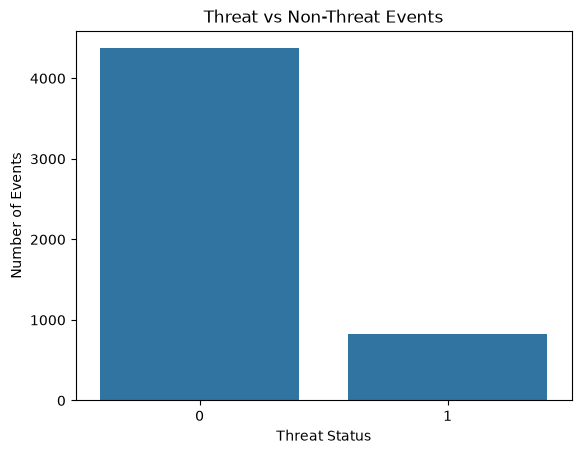

In [69]:
sns.countplot(x="Is_Threat", data=df)

plt.title("Threat vs Non-Threat Events")
plt.xlabel("Threat Status")
plt.ylabel("Number of Events")
plt.show()

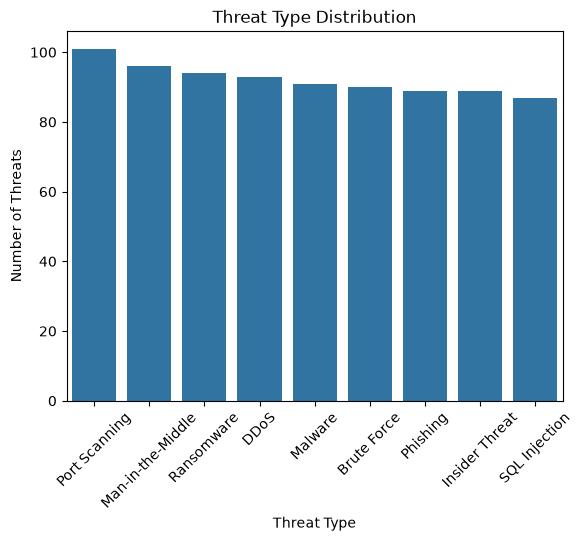

In [70]:
threat_type_counts = df[df["Is_Threat"] == 1]["Threat_Type"].value_counts()
sns.barplot(
    x=threat_type_counts.index,
    y=threat_type_counts.values
)
plt.title("Threat Type Distribution")
plt.xlabel("Threat Type")
plt.ylabel("Number of Threats")
plt.xticks(rotation=45)
plt.show()

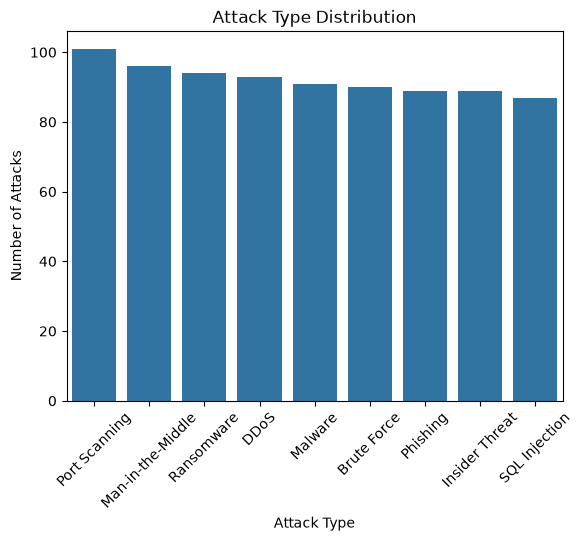

In [71]:
attack_type_counts = df[df["Is_Threat"] == 1]["Attack_Type"].value_counts()
sns.barplot(
    x=attack_type_counts.index,
    y=attack_type_counts.values
)
plt.title("Attack Type Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45)
plt.show()

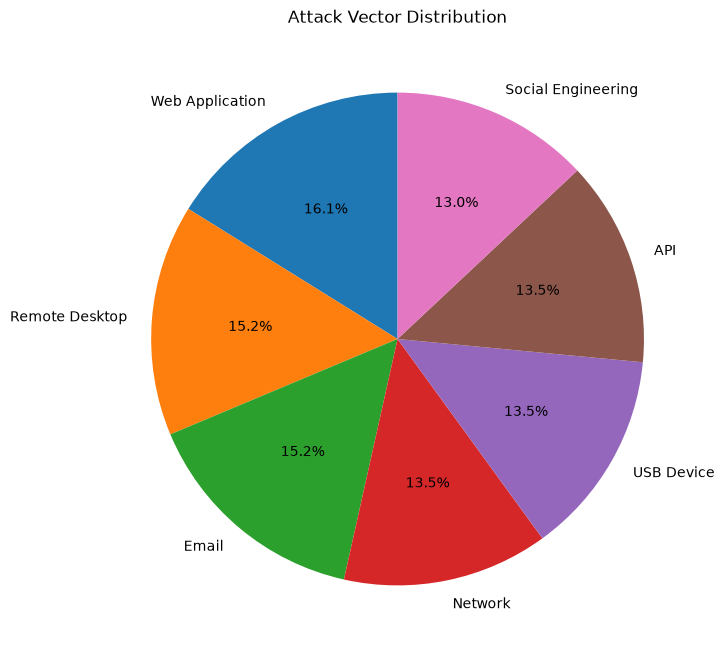

In [72]:
attack_vector_counts = (
    df[df["Is_Threat"] == 1]["Attack_Vector"]
    .value_counts()
)
plt.figure(figsize=(8, 8))
plt.pie(
    attack_vector_counts.values,
    labels=attack_vector_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Attack Vector Distribution")
plt.show()

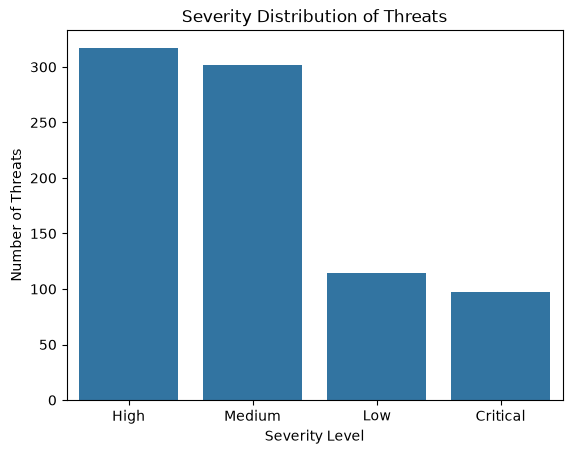

In [73]:
severity_counts = (
    df[df["Is_Threat"] == 1]["Severity"]
    .value_counts()
)
sns.countplot(
    x="Severity",
    data=df[df["Is_Threat"] == 1],
    order=severity_counts.index
)
plt.title("Severity Distribution of Threats")
plt.xlabel("Severity Level")
plt.ylabel("Number of Threats")
plt.show()

           Malware Detected  Suspicious URL  Unusual Port  \
Is_Threat                                                   
0                  0.016934        0.029062      0.000000   
1                  0.562651        0.495181      0.561446   

           Multiple Failed Logins  
Is_Threat                          
0                        0.003204  
1                        0.516867  


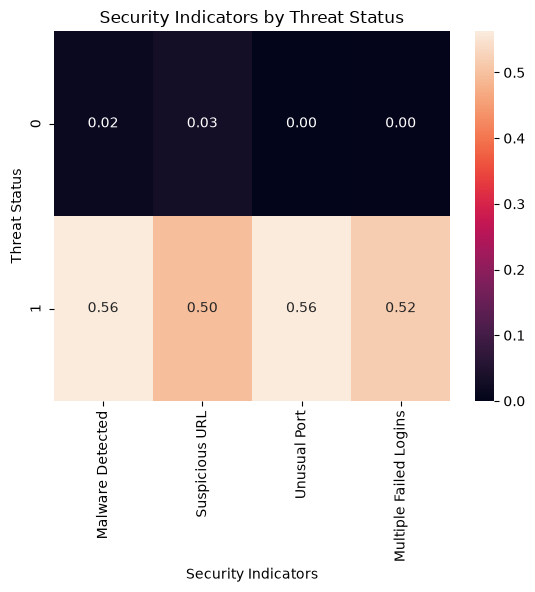

In [74]:
security_indicators = pd.DataFrame({
    "Malware Detected": df.groupby("Is_Threat")["Malware_Detected"].mean(),
    "Suspicious URL": df.groupby("Is_Threat")["Suspicious_URL"].mean(),
    "Unusual Port": df.groupby("Is_Threat")["Unusual_Port"].mean(),
    "Multiple Failed Logins": df.groupby("Is_Threat")["Multiple_Failed_Logins"].mean()
})
print(security_indicators)
sns.heatmap(
    security_indicators,
    annot=True,
    fmt=".2f"
)
plt.title("Security Indicators by Threat Status")
plt.xlabel("Security Indicators")
plt.ylabel("Threat Status")
plt.show()

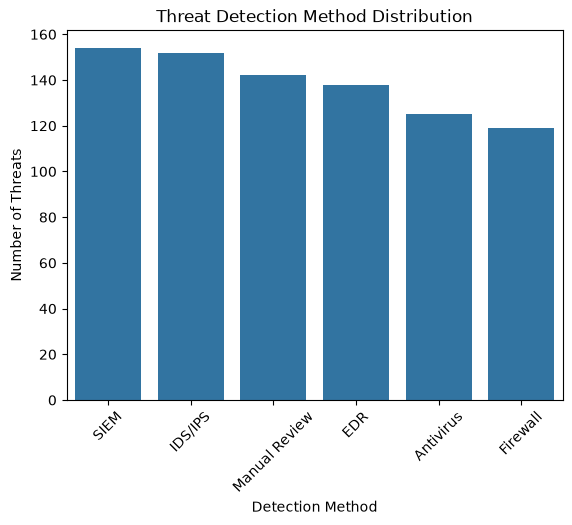

In [75]:
detection_method_counts = (
    df[df["Is_Threat"] == 1]["Detection_Method"]
    .value_counts()
)
sns.barplot(
    x=detection_method_counts.index,
    y=detection_method_counts.values
)
plt.title("Threat Detection Method Distribution")
plt.xlabel("Detection Method")
plt.ylabel("Number of Threats")
plt.xticks(rotation=45)
plt.show()

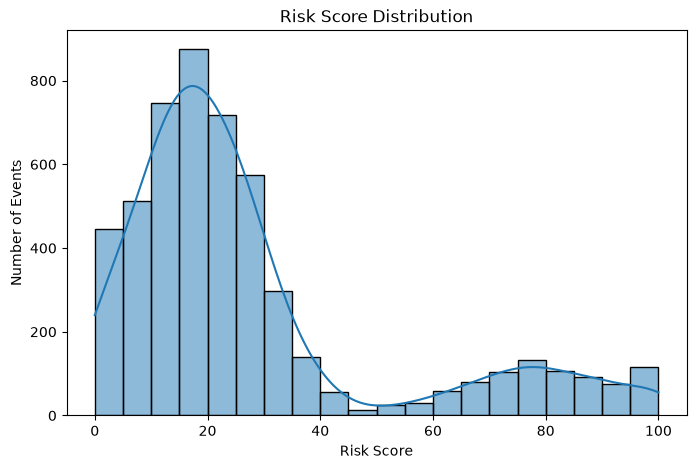

In [76]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Risk_Score"],
    bins=20,
    kde=True
)

plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Number of Events")
plt.show()

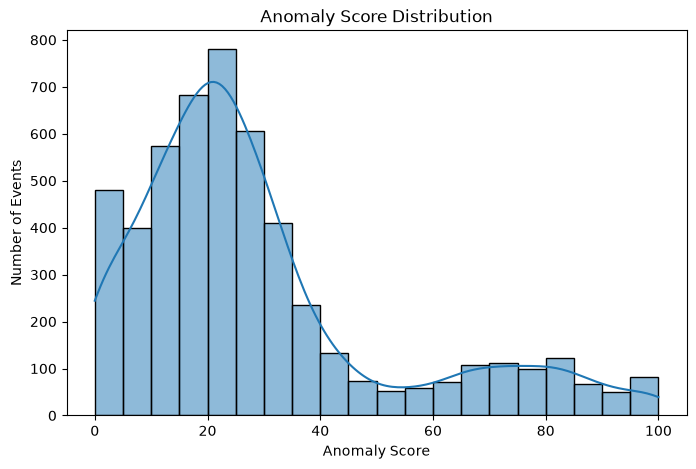

In [77]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df["Anomaly_Score"],
    bins=20,
    kde=True
)
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Events")
plt.show()

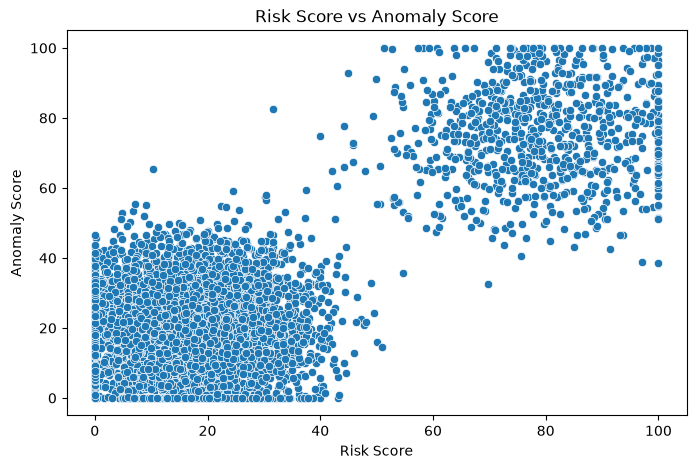

In [78]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="Risk_Score",
    y="Anomaly_Score",
    data=df
)
plt.title("Risk Score vs Anomaly Score")
plt.xlabel("Risk Score")
plt.ylabel("Anomaly Score")
plt.show()

## 12. Key Cybersecurity Insights

The major findings from the analysis are summarized to identify important cybersecurity patterns and risk indicators.

In [79]:
threat_counts = df["Is_Threat"].value_counts()
threat_percentage = df["Is_Threat"].value_counts(normalize=True) * 100

print("Total Events:", len(df))
print("Non-Threat Events:", threat_counts[0])
print("Threat Events:", threat_counts[1])
print("Threat Percentage:", threat_percentage[1])
print("Non-Threat Percentage:", threat_percentage[0])

Total Events: 5200
Non-Threat Events: 4370
Threat Events: 830
Threat Percentage: 15.96153846153846
Non-Threat Percentage: 84.03846153846153


In [80]:
print("Most Common Threat Type:")
print(threat_type_counts.head(1))

Most Common Threat Type:
Threat_Type
Port Scanning    101
Name: count, dtype: int64


In [81]:
print("Most Common Attack Type:")
print(attack_type_counts.head(1))

Most Common Attack Type:
Attack_Type
Port Scanning    101
Name: count, dtype: int64


In [82]:
print("Most Common Attack Vector:")
print(attack_vector_counts.head(1))

Most Common Attack Vector:
Attack_Vector
Web Application    134
Name: count, dtype: int64


In [83]:
print("Severity Distribution:")
print(severity_counts)

print("\nMost Common Severity:")
print(severity_counts.head(1))

Severity Distribution:
Severity
High        317
Medium      302
Low         114
Critical     97
Name: count, dtype: int64

Most Common Severity:
Severity
High    317
Name: count, dtype: int64


In [84]:
print("Malware Detection:")
print(malware_threat)

print("\nSuspicious URL:")
print(suspicious_url_threat)

print("\nUnusual Port:")
print(unusual_port_threat)

print("\nMultiple Failed Logins:")
print(failed_login_threat)

Malware Detection:
Malware_Detected     0    1
Is_Threat                  
0                 4296   74
1                  363  467

Suspicious URL:
Suspicious_URL     0    1
Is_Threat                
0               4243  127
1                419  411

Unusual Port:
Unusual_Port     0    1
Is_Threat              
0             4370    0
1              364  466

Multiple Failed Logins:
Multiple_Failed_Logins     0    1
Is_Threat                        
0                       4356   14
1                        401  429


In [85]:
print("Average Risk Score by Threat Status:")
print(risk_by_threat)

print("\nAverage Anomaly Score by Threat Status:")
print(anomaly_by_threat)

Average Risk Score by Threat Status:
Is_Threat
0    17.945709
1    78.870205
Name: Risk_Score, dtype: float64

Average Anomaly Score by Threat Status:
Is_Threat
0    20.178950
1    75.194217
Name: Anomaly_Score, dtype: float64


In [86]:
print("High Risk Events (Risk Score > 70):", len(high_risk))

High Risk Events (Risk Score > 70): 625


In [87]:
print("Login Activity by Threat Status:")
print(login_analysis)

Login Activity by Threat Status:
           Login_Attempts  Failed_Login_Count  Successful_Login_Count
Is_Threat                                                            
0                1.726087            0.976430                0.749657
1                5.513253            5.022892                0.490361


## Key Cybersecurity Insights

1. Threat prevalence:
   The dataset contains 5,200 events, of which 830 were identified as threats.

2. Threat patterns:
   The most common threat type, attack type, and attack vector were identified from the detected threats.

3. Severity:
   The severity distribution helps identify the most frequently occurring level of threat seriousness.

4. Security indicators:
   Malware detection, suspicious URLs, unusual ports, and multiple failed logins were compared between threat and non-threat events.

5. Risk and anomaly:
   Average Risk Score and Anomaly Score were compared between threat and non-threat events.

6. High-risk events:
   Events with Risk Score above 70 were identified as high-risk events requiring further investigation.

7. Login behavior:
   Login attempts, failed logins, and successful logins were compared to identify suspicious authentication behavior.

## Project Conclusion

This project analyzed cybersecurity events to identify threats, attack patterns, security indicators, risk levels, and suspicious user behavior.

The analysis showed how data cleaning, exploratory data analysis, statistical analysis, and visualization can be combined to understand cybersecurity threats.

Risk Score, Anomaly Score, security indicators, attack patterns, and login behavior were analyzed to identify potentially suspicious events.

The findings can help security teams prioritize high-risk events and improve threat monitoring and detection.

Overall, this project demonstrates the use of Python, Pandas, NumPy, Matplotlib, and Seaborn for cybersecurity threat analysis.